In [39]:
#importing the .xls file for the dataset
from google.colab import files

uploaded = files.upload()


Saving Absenteeism_at_work_Project.xls to Absenteeism_at_work_Project (2).xls


In [40]:
#the libraries importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [41]:
#info about the dataset
df = pd.read_excel("Absenteeism_at_work_Project.xls")

df.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26.0,7.0,3,1,289.0,36.0,13.0,33.0,239554.0,...,0.0,1.0,2.0,1.0,0.0,1.0,90.0,172.0,30.0,4.0
1,36,0.0,7.0,3,1,118.0,13.0,18.0,50.0,239554.0,...,1.0,1.0,1.0,1.0,0.0,0.0,98.0,178.0,31.0,0.0
2,3,23.0,7.0,4,1,179.0,51.0,18.0,38.0,239554.0,...,0.0,1.0,0.0,1.0,0.0,0.0,89.0,170.0,31.0,2.0
3,7,7.0,7.0,5,1,279.0,5.0,14.0,39.0,239554.0,...,0.0,1.0,2.0,1.0,1.0,0.0,68.0,168.0,24.0,4.0
4,11,23.0,7.0,5,1,289.0,36.0,13.0,33.0,239554.0,...,0.0,1.0,2.0,1.0,0.0,1.0,90.0,172.0,30.0,2.0


In [42]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               737 non-null    float64
 2   Month of absence                 739 non-null    float64
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           733 non-null    float64
 6   Distance from Residence to Work  737 non-null    float64
 7   Service time                     737 non-null    float64
 8   Age                              737 non-null    float64
 9   Work load Average/day            730 non-null    float64
 10  Hit target                       734 non-null    float64
 11  Disciplinary failure             734 non-null    float64
 12  Education             

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
count,740.000000,737.000000,739.000000,740.000000,740.000000,733.000000,737.000000,737.000000,737.000000,730.000000,...,734.000000,730.000000,734.000000,737.000000,736.000000,738.000000,739.000000,726.000000,709.000000,718.000000
mean,18.017568,19.188602,6.319350,3.914865,2.544595,221.035471,29.667571,12.565807,36.449118,271188.860274,...,0.053134,1.295890,1.017711,0.567164,0.073370,0.746612,79.063599,172.152893,26.684062,6.977716
std,11.021247,8.437493,3.435948,1.421675,1.111831,66.954179,14.848124,4.389813,6.480148,38981.880873,...,0.224453,0.676965,1.094928,0.495805,0.260919,1.319726,12.868630,6.081065,4.292819,13.476962
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,205917.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,244387.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,264249.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,284853.000000,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,378884.000000,...,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


In [43]:
#Data cleaning
df.isnull().sum()

#this is to the if there are any duplicates
df.duplicated().sum()

np.int64(25)

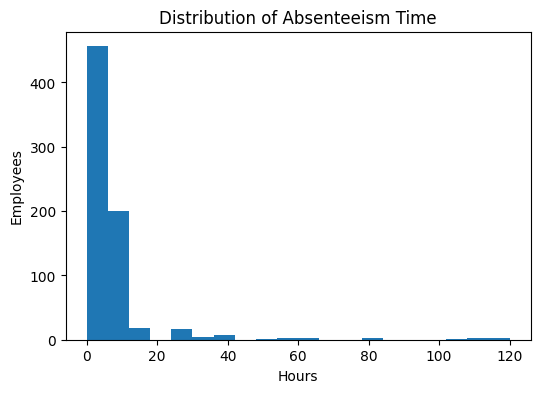

In [57]:
#time vs employees absenteeism
plt.figure(figsize=(6,4))
plt.hist(df["Absenteeism time in hours"], bins=20)

plt.title("Distribution of Absenteeism Time")
plt.xlabel("Hours")
plt.ylabel("Employees")
plt.savefig("distribution1.png")
plt.show()

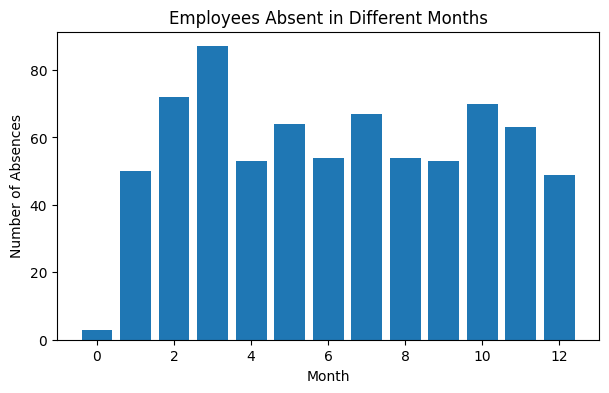

In [58]:
##month and absenteeism distribution
month = df["Month of absence"].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(month.index, month.values)

plt.title("Employees Absent in Different Months")
plt.xlabel("Month")
plt.ylabel("Number of Absences")

plt.savefig("distribution2.png")
plt.show()

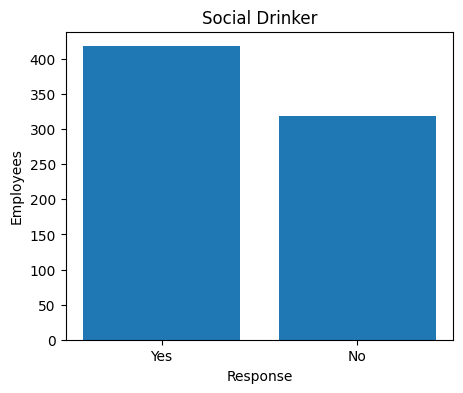

In [59]:
#social drinker vs absenteeism
drink = df["Social drinker"].replace({0:"No",1:"Yes"})

count = drink.value_counts()

plt.figure(figsize=(5,4))
plt.bar(count.index, count.values)

plt.title("Social Drinker")
plt.xlabel("Response")
plt.ylabel("Employees")

plt.savefig("distribution3.png")
plt.show()

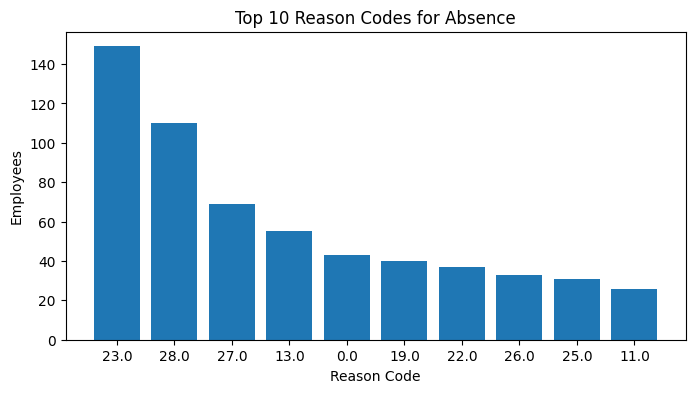

In [60]:
#most common reasons graph chart
reason = df["Reason for absence"].value_counts().head(10)

plt.figure(figsize=(8,4))
plt.bar(reason.index.astype(str), reason.values)

plt.title("Top 10 Reason Codes for Absence")
plt.xlabel("Reason Code")
plt.ylabel("Employees")

plt.savefig("distribution4.png")
plt.show()

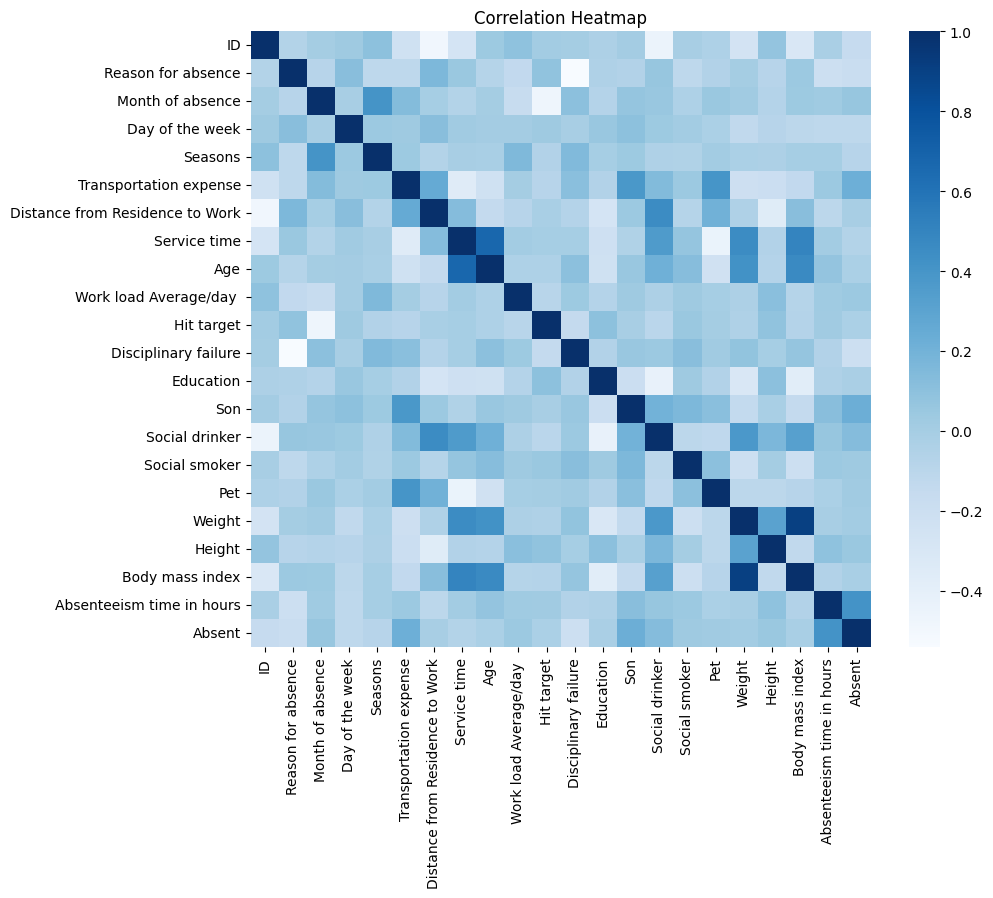

In [61]:
#the correlation heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="Blues")

plt.title("Correlation Heatmap")

plt.savefig("distribution5.png")
plt.show()

In [49]:
#feature engineering setup
mid = df["Absenteeism time in hours"].median()

df["Absent"] = (df["Absenteeism time in hours"] > mid).astype(int)

In [50]:
df["Absent"].value_counts()

,count
Absent,
0,411
1,329


In [51]:
#encoding the columns
x = df.drop(["Absenteeism time in hours","Absent"], axis=1)

y = df["Absent"]
x = pd.get_dummies(
    x,
    columns=["Reason for absence","Education","Seasons"],
    drop_first=True
)
x = x.fillna(0)

In [52]:
#the train test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
scale = StandardScaler()

x_train = scale.fit_transform(x_train)

x_test = scale.transform(x_test)

In [53]:
#logistic regression model
model = LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

#predction
pred = model.predict(x_test)

#evaluating the model
print("Accuracy :",accuracy_score(y_test,pred))

print("Precision :",precision_score(y_test,pred))

print("Recall :",recall_score(y_test,pred))

print("F1 Score :",f1_score(y_test,pred))

Accuracy : 0.7837837837837838
Precision : 0.7777777777777778
Recall : 0.7313432835820896
F1 Score : 0.7538461538461538


In [54]:
#predictions of the model based on the learning
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
})

result.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,1,0
5,0,0
6,0,0
7,1,1
8,1,1
9,0,0


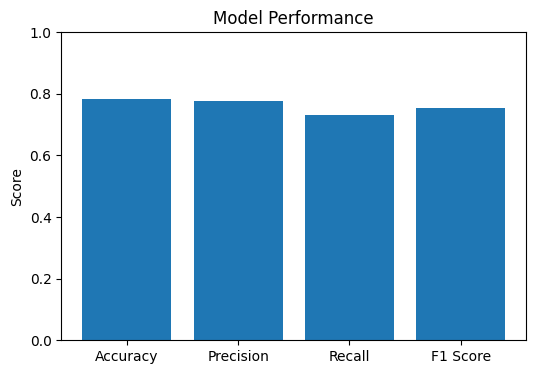

In [56]:
#graph of the model performance
scores = [
    accuracy_score(y_test, pred),
    precision_score(y_test, pred),
    recall_score(y_test, pred),
    f1_score(y_test, pred)
]

names = ["Accuracy", "Precision", "Recall", "F1 Score"]

plt.figure(figsize=(6,4))
plt.bar(names, scores)

plt.title("Model Performance")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

In [55]:
print("Employee Absenteeism Prediction Completed")

Employee Absenteeism Prediction Completed
